In [2]:
# Demo file for showing the different ways of quantile calculation
# based on ain_vl20260326.ipynb
#
# copyright: Barbara Staehle, HTWG Konstanz
# bstaehle@htwg-konstanz.de
# 08/2026

# import library we use for plotting and calculating
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math 

In [3]:
# read data from excelfile
# for excel-file, see Moodle!
umfrage = pd.read_excel('../../data/zehn_Fragen_ss26_clean.xlsx')
# select answers to one question as data for example 
data = umfrage['Q05_Stochastik-Vorwissen'] 
merkmal = 'Stochastik-Vorwissen'
sem = 'SS26'
# path where figures are stored (for later use in lecture Script)
figpath = ('../../bilder/')


Werte in der Liste: [0 1 2 3 4 5 6 7 8]
Absolute Häufigkeiten: [2 3 4 3 5 2 3 2 1]


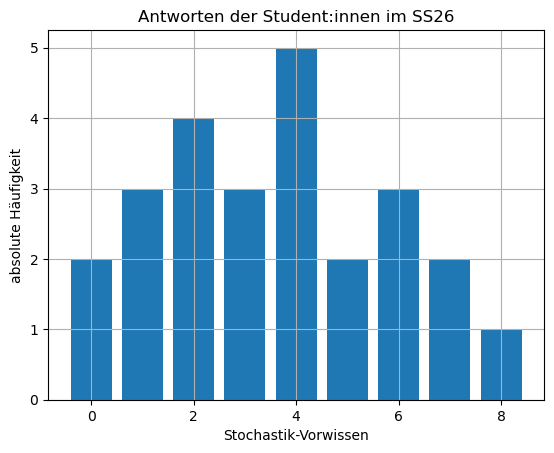

In [4]:
# create histogram of answers

# count how often each value occurs
values, counts = np.unique(data,return_counts=True)
print(f'Werte in der Liste: {values}')
print(f'Absolute Häufigkeiten: {counts}')

# show as bar plot 
fig = plt.figure()   
plt.bar(values,counts)
plt.grid(True)
plt.xlabel(merkmal)
plt.ylabel('absolute Häufigkeit')
plt.title('Antworten der Student:innen im ' + sem)
plt.show()
fig.savefig(figpath + 'vorwissen' + sem +'.png')

In [6]:
# Quantilberechnungsformel wie im Skript
def my_quantile(d, p):
   """
    Original in Matlab von Barbara Staehle, Übersetzung nach Python: LeChat, 
    Anpassung auf p kann Skalar ODER Array sein mittels vieler Iterationen durch Vibe
   """
   
   ds = np.sort(d)
   n = len(d)
   p_arr = np.asarray(p, dtype=float)

   # korrigiere, falls Angaben in Prozent waren 
   if np.any(p_arr > 1):
      p_arr = p_arr/100
       
   np_val = n * p_arr
   result = np.zeros_like(p_arr)
   
   # Sonderfälle: p=0 → Minimum, p=1 → Maximum
   result[p_arr == 0] = ds[0]
   result[p_arr == 1] = ds[-1]
    
   # 0 < p < 1: Original-Logik
   mask = (p_arr > 0) & (p_arr < 1)
   if np.any(mask):
       np_val_mask = np_val[mask]
       is_integer = np.isclose(np_val_mask % 1, 0)
       k_int = np_val_mask[is_integer].astype(int)
       k_nonint = np.ceil(np_val_mask[~is_integer]).astype(int) - 1
   
       result_mask = np.empty_like(np_val_mask)
       result_mask[is_integer] = (ds[k_int-1] + ds[k_int]) / 2
       result_mask[~is_integer] = ds[k_nonint]
       result[mask] = result_mask
    
   return result.item() if np.isscalar(p) else result
    

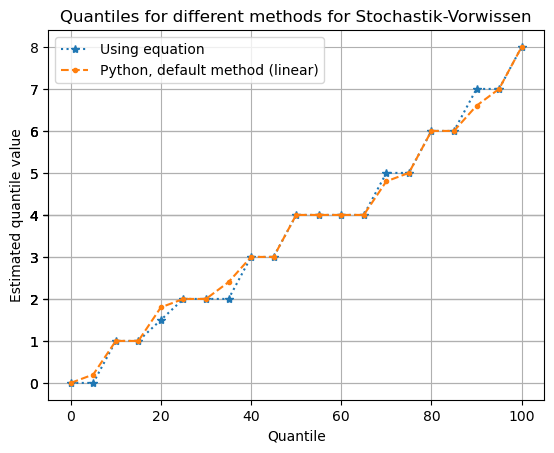

In [9]:
# Example adapted from https://numpy.org/doc/stable/reference/generated/numpy.percentile.html#numpy.percentile
# Original-Beispiel
#a = np.arange(8) # [0,1,2,3]

#replace by Stochastik-Vorwissen
a = np.array(data)

# the p-values to look at [0,5,10,...,100]%
p = np.linspace(0, 100, 21) 
fig = plt.figure()  
ax = plt.gca()

# plot all quantiles calculated via formula
ax.plot(
        p, my_quantile(a,p),label = 'Using equation', linestyle = ':', marker='*', color='C0')

# plot all quantiles calculated via default Python method
ax.plot(
        p, np.percentile(a, p),
        label='Python, default method (linear)', linestyle='--', marker='.', color='C1')
    
ax.set(
    title='Quantiles for different methods for ' + merkmal , # + ' : ' + str(a),
    xlabel='Quantile',
    ylabel='Estimated quantile value',
    yticks=a)
ax.legend() 
plt.grid(True)
plt.show()
fig.savefig(figpath + 'vorwissen' + sem +'_quantileFormula_Python1.png')

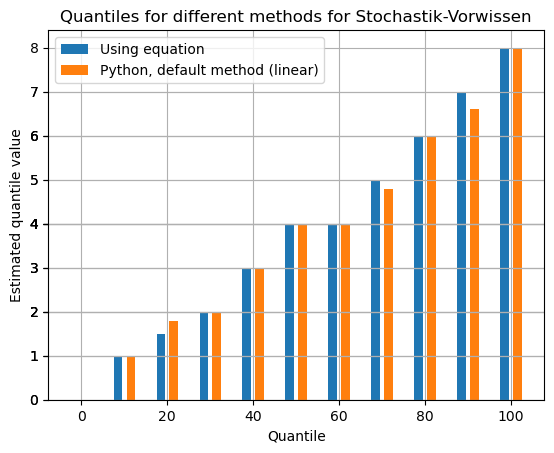

In [13]:
# Same data points as above but different plot (use bar plot instead and reduce number of p-values)

p = np.linspace(0, 100, 11) 

fig = plt.figure()
ax = plt.gca()
plt.grid(True)

ax.bar(
        p-1.5, my_quantile(a,p),label = 'Using equation',  width=2, color='C0')

ax.bar(
        p+1.5, np.percentile(a, p),
        label='Python, default method (linear)', width=2, color='C1'
)
    
ax.set(
    title='Quantiles for different methods for ' + merkmal , # + ' : ' + str(a),
    xlabel='Quantile',
    ylabel='Estimated quantile value',
    yticks=a)
ax.legend() 

plt.show()
fig.savefig(figpath + 'vorwissen' + sem +'_quantileFormula_Python1_bar.png')

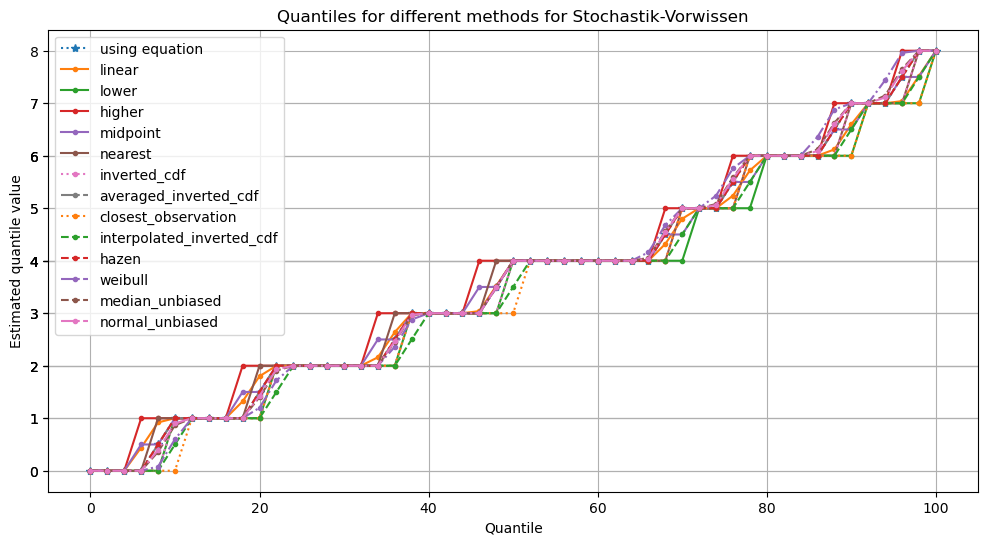

In [14]:
# Example with all methods 
# adapted from https://numpy.org/doc/stable/reference/generated/numpy.percentile.html#numpy.percentile

# use more values for p 
p = np.linspace(0, 100, 51) 

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()

# plot each method with different linestyle and colo
lines = [
    ('linear', '-', 'C1'), # default method
    ('lower','-', 'C2'),
    ('higher','-', 'C3'),
    ('midpoint','-', 'C4'),
    ('nearest','-', 'C5'),
    ('inverted_cdf', ':', 'C6'),
    ('averaged_inverted_cdf', '-.', 'C7'),
    ('closest_observation', ':', 'C1'),
    ('interpolated_inverted_cdf', '--', 'C2'),
    ('hazen', '--', 'C3'),
    ('weibull', '-.', 'C4'),
    ('median_unbiased', '--', 'C5'),
    ('normal_unbiased', '-.', 'C6')
    ]

# values from formula
ax.plot(
        p, my_quantile(a,p),label = 'using equation', linestyle = ':',marker = '*', color = 'C0')

# iterate over all Python methods
for method, style, color in lines:
    ax.plot(
        p, np.percentile(a, p, method=method),
        label=method, linestyle=style, color=color,marker = '.')
    
ax.set(
    title='Quantiles for different methods for ' + merkmal, #data: ' + str(a),
    xlabel='Quantile',
    ylabel='Estimated quantile value',
    yticks=a)
ax.legend() 
plt.grid(True)
plt.show()
fig.savefig(figpath + 'vorwissen' + sem +'_quantileFormula_Python_many.png')

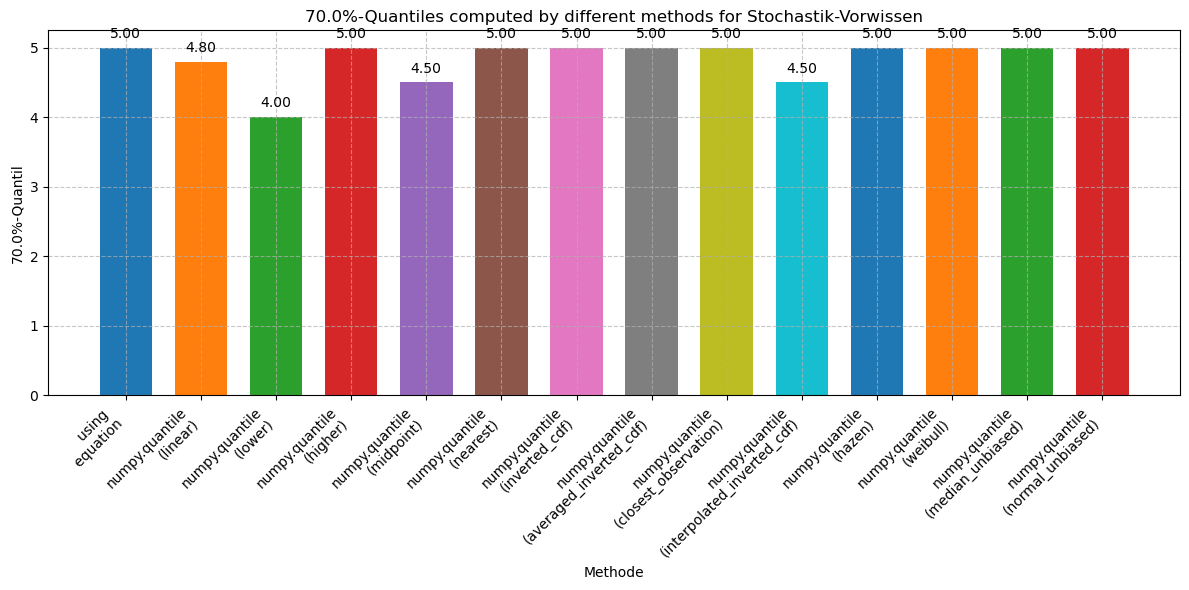

In [15]:
# Berechne das p*10%-Quantil mit allen Methoden für die Gruppe "data"
# Coauthor: LeChat
p = 0.7
methods = {
     'using \n equation':        my_quantile(data, p),
     'numpy.quantile\n(linear)':               np.quantile(data, p, method='linear'),
    'numpy.quantile\n(lower)':                np.quantile(data, p, method='lower'),
    'numpy.quantile\n(higher)':               np.quantile(data, p, method='higher'),
    'numpy.quantile\n(midpoint)':             np.quantile(data, p, method='midpoint'),
    'numpy.quantile\n(nearest)':              np.quantile(data, p, method='nearest'),
    'numpy.quantile\n(inverted_cdf)':         np.quantile(data, p, method='inverted_cdf'),
    'numpy.quantile\n(averaged_inverted_cdf)':np.quantile(data, p, method='averaged_inverted_cdf'),
    'numpy.quantile\n(closest_observation)':  np.quantile(data, p, method='closest_observation'),
    'numpy.quantile\n(interpolated_inverted_cdf)': np.quantile(data, p, method='interpolated_inverted_cdf'),
    'numpy.quantile\n(hazen)':                np.quantile(data, p, method='hazen'),
    'numpy.quantile\n(weibull)':              np.quantile(data, p, method='weibull'),
    'numpy.quantile\n(median_unbiased)':      np.quantile(data, p, method='median_unbiased'),
    'numpy.quantile\n(normal_unbiased)':      np.quantile(data, p, method='normal_unbiased')
}

# Positionen für Quantile-Balken
x = np.arange(len(methods))  # Positionen für die Methoden
width = 0.7  # Breite der Balken

# Plot erstellen
fig = plt.figure(figsize=(12, 6))

# Balken für die Quantile aller Methoden
bars = plt.bar(x, methods.values(), width=width,
               color=[f'C{i}' for i in range(len(methods))])

# Titel und Beschriftungen
plt.title(f'{p*100}%-Quantiles computed by different methods for {merkmal}')
plt.xlabel('Methode')
plt.ylabel(f'{p*100}%-Quantil')
plt.xticks(x, methods.keys(), rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)

# Werte auf die Balken schreiben
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.02 * max(methods.values()),
             f'{height:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()
fig.savefig(figpath + 'vorwissen' + sem +'_quantileFormula_Python_many_bars.png')